## Step 1: Import the required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)      # makes the random numbers repeatable
print("Libraries imported successfully!")

Libraries imported successfully!


## Part A: Normal Distribution

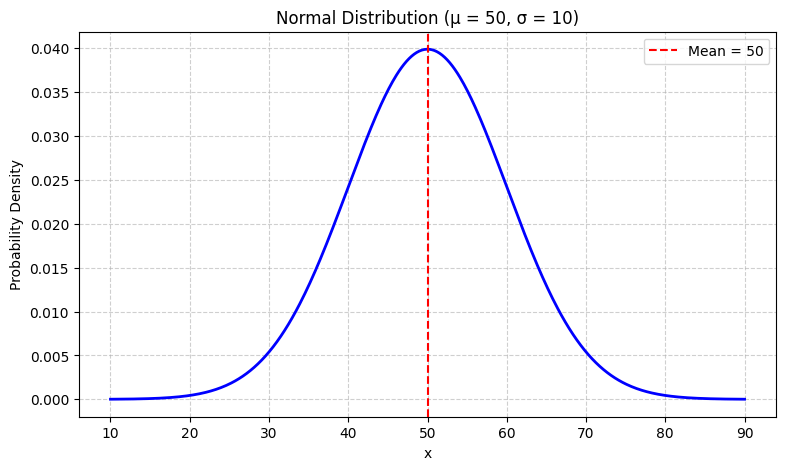

In [2]:
# Step 2: Parameters
mu = 50        # mean
sigma = 10     # standard deviation

# Step 3: Create x values covering mean +/- 4 standard deviations
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)

# Step 4: pdf = Probability Density Function (height of the curve)
normal_pdf = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(9, 5))
plt.plot(x, normal_pdf, color="blue", linewidth=2)
plt.title("Normal Distribution (μ = 50, σ = 10)")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.axvline(mu, color="red", linestyle="--", label="Mean = 50")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [3]:
# Step 5: Probability calculations (cdf gives area to the LEFT of a value)
print("P(X < 60)        =", round(stats.norm.cdf(60, mu, sigma), 4))
print("P(X > 65)        =", round(1 - stats.norm.cdf(65, mu, sigma), 4))
print("P(40 < X < 60)   =", round(stats.norm.cdf(60, mu, sigma) - stats.norm.cdf(40, mu, sigma), 4))

# Empirical rule check
print("\nEmpirical (68-95-99.7) rule:")
for k in [1, 2, 3]:
    area = stats.norm.cdf(mu + k * sigma, mu, sigma) - stats.norm.cdf(mu - k * sigma, mu, sigma)
    print(f"  Within {k} std dev: {area * 100:.2f} %")

P(X < 60)        = 0.8413
P(X > 65)        = 0.0668
P(40 < X < 60)   = 0.6827

Empirical (68-95-99.7) rule:
  Within 1 std dev: 68.27 %
  Within 2 std dev: 95.45 %
  Within 3 std dev: 99.73 %


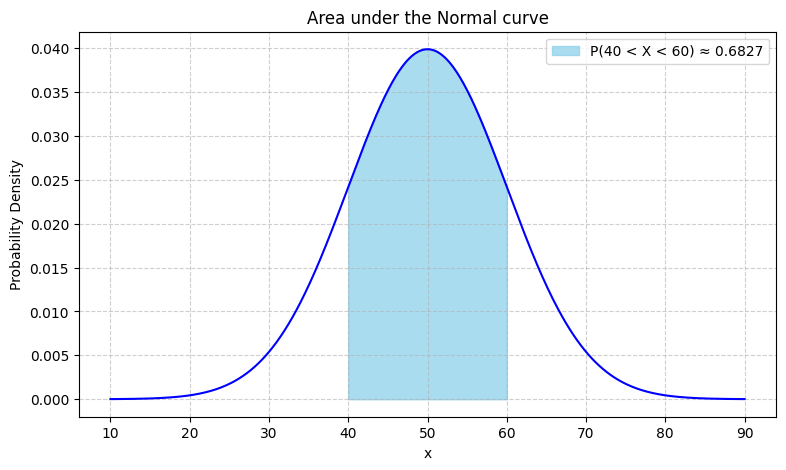

In [4]:
# Step 6: Shade the area between 40 and 60
plt.figure(figsize=(9, 5))
plt.plot(x, normal_pdf, color="blue")
x_fill = np.linspace(40, 60, 200)
plt.fill_between(x_fill, stats.norm.pdf(x_fill, mu, sigma), color="skyblue", alpha=0.7,
                 label="P(40 < X < 60) ≈ 0.6827")
plt.title("Area under the Normal curve")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

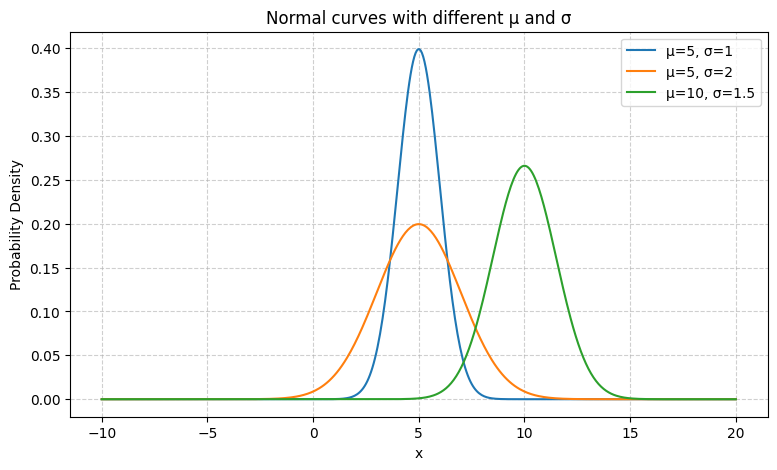

In [5]:
# Step 7: Effect of changing mean and standard deviation
x2 = np.linspace(-10, 20, 500)

plt.figure(figsize=(9, 5))
plt.plot(x2, stats.norm.pdf(x2, 5, 1), label="μ=5, σ=1")
plt.plot(x2, stats.norm.pdf(x2, 5, 2), label="μ=5, σ=2")
plt.plot(x2, stats.norm.pdf(x2, 10, 1.5), label="μ=10, σ=1.5")
plt.title("Normal curves with different μ and σ")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Part B: Exponential Distribution

**Problem:** Customers arrive at a shop at an average rate of **0.5 per minute** (λ = 0.5). So the average waiting time is 1/λ = 2 minutes.

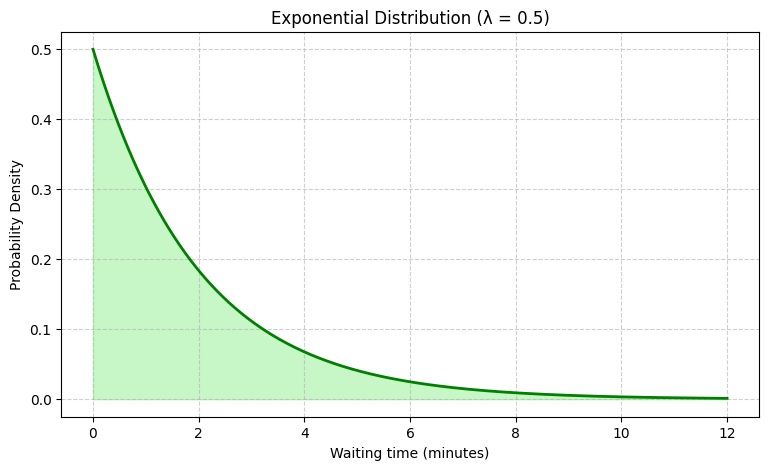

In [6]:
# Step 8: Parameters
rate = 0.5                  # lambda
scale = 1 / rate            # SciPy uses scale = 1/lambda

x_exp = np.linspace(0, 12, 500)
exp_pdf = stats.expon.pdf(x_exp, scale=scale)

plt.figure(figsize=(9, 5))
plt.plot(x_exp, exp_pdf, color="green", linewidth=2)
plt.fill_between(x_exp, exp_pdf, color="lightgreen", alpha=0.5)
plt.title("Exponential Distribution (λ = 0.5)")
plt.xlabel("Waiting time (minutes)")
plt.ylabel("Probability Density")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [7]:
# Step 9: Probability calculations
print("Mean waiting time         =", stats.expon.mean(scale=scale), "minutes")
print("P(wait < 2 min)           =", round(stats.expon.cdf(2, scale=scale), 4))
print("P(wait > 5 min)           =", round(1 - stats.expon.cdf(5, scale=scale), 4))
print("P(1 < wait < 3 min)       =", round(stats.expon.cdf(3, scale=scale) - stats.expon.cdf(1, scale=scale), 4))

Mean waiting time         = 2.0 minutes
P(wait < 2 min)           = 0.6321
P(wait > 5 min)           = 0.0821
P(1 < wait < 3 min)       = 0.3834


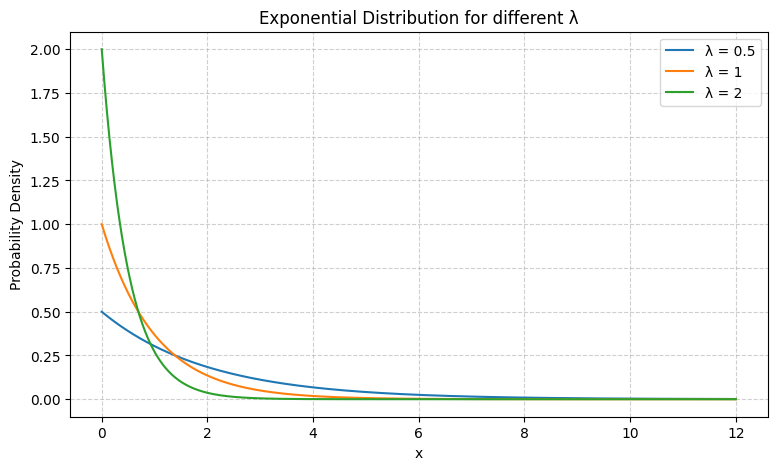

In [8]:
# Step 10: Effect of changing the rate
plt.figure(figsize=(9, 5))
for r in [0.5, 1, 2]:
    plt.plot(x_exp, stats.expon.pdf(x_exp, scale=1 / r), label=f"λ = {r}")
plt.title("Exponential Distribution for different λ")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Part C: Central Limit Theorem (CLT)

We will take samples from the **Exponential distribution** (which is NOT bell-shaped, it is heavily skewed) and show that the **averages of samples** still form a bell curve.

**Plan:**
1. Draw a large population from the Exponential distribution.
2. Repeatedly take a random sample of size `n` and calculate its mean.
3. Plot a histogram of all those sample means.
4. Repeat for different sample sizes (n = 1, 5, 30, 100).

Population mean     = 1.992
Population std dev  = 1.986


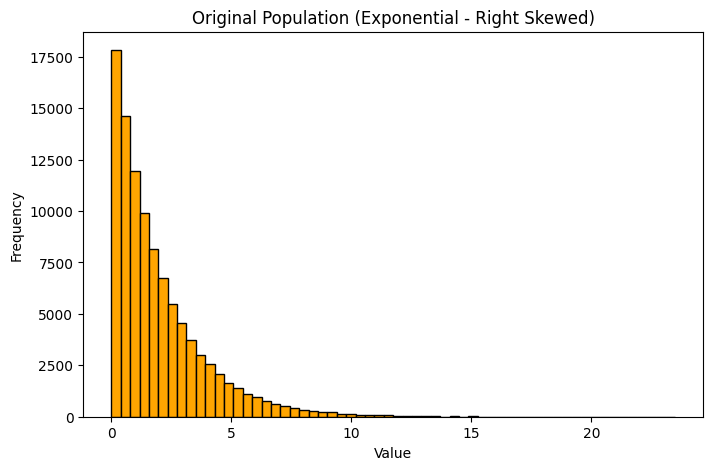

In [9]:
# Step 11: The original (non-normal) population
population = np.random.exponential(scale=2, size=100000)

print("Population mean     =", round(population.mean(), 3))
print("Population std dev  =", round(population.std(), 3))

plt.figure(figsize=(8, 5))
plt.hist(population, bins=60, color="orange", edgecolor="black")
plt.title("Original Population (Exponential - Right Skewed)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

n =   1 -> mean of sample means = 1.966, std of sample means = 1.933
n =   5 -> mean of sample means = 1.993, std of sample means = 0.858
n =  30 -> mean of sample means = 2.013, std of sample means = 0.365
n = 100 -> mean of sample means = 1.995, std of sample means = 0.199


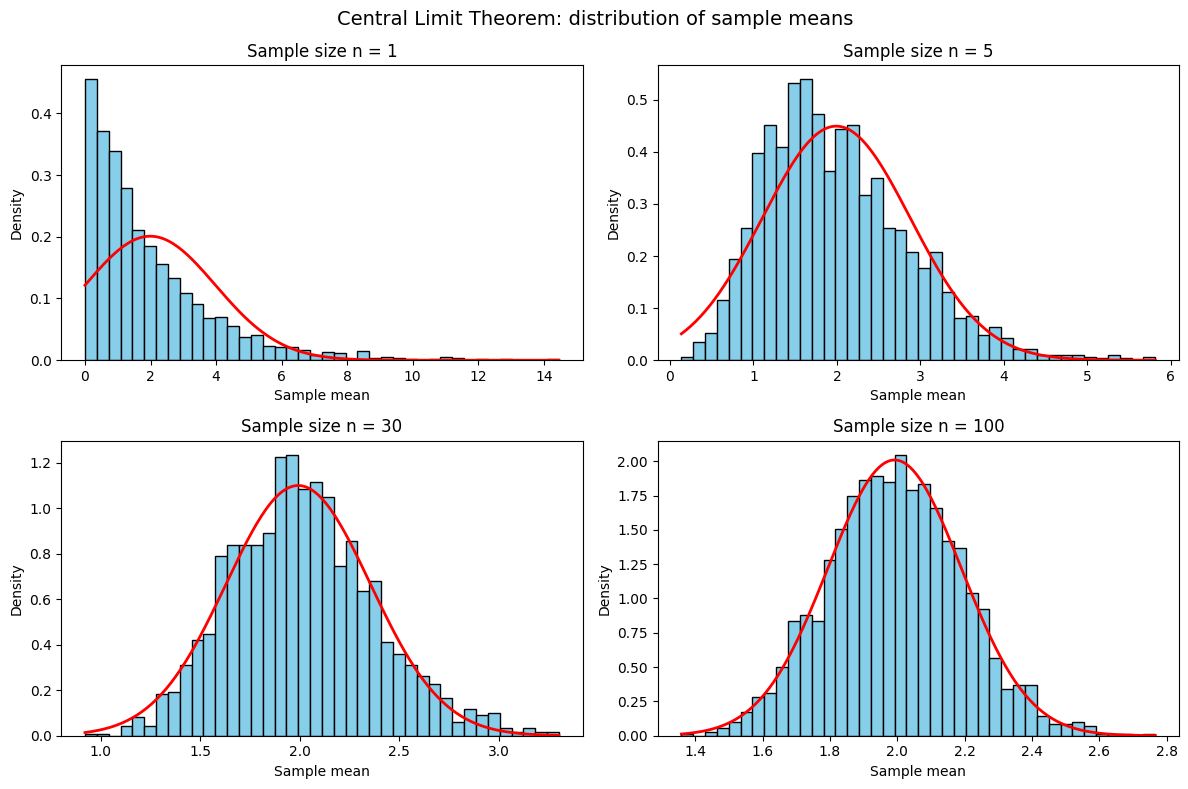

In [10]:
# Step 12: Take many samples and record their means
num_samples = 2000                   # how many times we repeat sampling
sample_sizes = [1, 5, 30, 100]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, n in zip(axes, sample_sizes):
    sample_means = []
    for _ in range(num_samples):
        sample = np.random.choice(population, size=n)   # pick n random values
        sample_means.append(sample.mean())              # store the mean

    sample_means = np.array(sample_means)

    # histogram of sample means
    ax.hist(sample_means, bins=40, density=True, color="skyblue", edgecolor="black")

    # overlay the theoretical normal curve predicted by CLT
    xs = np.linspace(sample_means.min(), sample_means.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, population.mean(), population.std() / np.sqrt(n)),
            color="red", linewidth=2)

    ax.set_title(f"Sample size n = {n}")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Density")
    print(f"n = {n:3d} -> mean of sample means = {sample_means.mean():.3f}, "
          f"std of sample means = {sample_means.std():.3f}")

plt.suptitle("Central Limit Theorem: distribution of sample means", fontsize=14)
plt.tight_layout()
plt.show()

### Observation
- For **n = 1** the histogram looks like the original skewed distribution.
- As **n increases**, the histogram becomes more and more **bell-shaped** (red curve = Normal).
- The mean of the sample means stays close to the population mean (≈ 2).
- The spread (standard deviation) of the sample means **decreases** as n grows: σ / √n.

## Conclusion

- The **Normal distribution** was plotted, probabilities were calculated, and the 68-95-99.7 rule was verified.
- The **Exponential distribution** was plotted and used to compute waiting-time probabilities.
- The **Central Limit Theorem** was demonstrated: even though the population was exponential (skewed), the distribution of sample means became approximately normal as the sample size increased.